
# 2. Correlación cruzada entre Calamar y las otras estaciones

Debido a que las estaciones explicativas se encuentran a varios cientos de kilómetros de la estación Calamar, se espera que exista un retardo
temporal entre las variables explicativas y la serie objetivo. Por lo tanto, se realiza inicialmente un análisis de correlación cruzada con el fin 
de identificar el desfase temporal más representativo y desplazar las series de tiempo de las variables explicativas según el lag encontrado, de manera
que se maximice su correlación con la estación de Calamar.

## 2.1. Lectura de archivos de nivel

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Rutas
rutas = {
    "Achi": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Achi.csv",
    "Calamar": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Calamar.csv",
    "ElBanco": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\ElBanco.csv",
    "SaladoBlanco": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\SaladoBlanco.csv",
    "PuertoBerrio": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\PuertoBerrio.csv",
    "Barrancabermeja": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Barrancabermeja.csv"
}

# Lectura
def leer_nivel(ruta, nombre):
    df = pd.read_csv(ruta, parse_dates=["Fecha"])
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Nivel"] = pd.to_numeric(df["Nivel"], errors="coerce")
    df = df.dropna(subset=["Fecha"]).sort_values("Fecha")

    # Eliminar fechas repetidas
    df = df.drop_duplicates(subset="Fecha", keep="first")

    return df[["Fecha", "Nivel"]].rename(columns={"Nivel": nombre})

# Leer series
series = {nombre: leer_nivel(ruta, nombre) for nombre, ruta in rutas.items()}



## 2.2. Rango de tiempo común entre series

In [56]:

# Tomar intervalo común
fecha_ini = max(df_["Fecha"].min() for df_ in series.values())
fecha_fin = min(df_["Fecha"].max() for df_ in series.values())

print("Fecha inicial común:", fecha_ini)
print("Fecha final común:", fecha_fin)

# Calendario completo dentro del intervalo común
calendario = pd.DataFrame({
    "Fecha": pd.date_range(start=fecha_ini, end=fecha_fin, freq="D")
})

# Unir series al calendario 
df = calendario.copy()
for nombre, dfi in series.items():
    dfi = dfi[(dfi["Fecha"] >= fecha_ini) & (dfi["Fecha"] <= fecha_fin)]
    df = df.merge(dfi, on="Fecha", how="left")

df = df.sort_values("Fecha").reset_index(drop=True)



Fecha inicial común: 1975-06-01 00:00:00
Fecha final común: 2025-11-10 00:00:00


## 2.3. Correlación cruzada

Achi -> Calamar: mejor lag = 16 días, correlación = 0.7321
ElBanco -> Calamar: mejor lag = 9 días, correlación = 0.9276
SaladoBlanco -> Calamar: mejor lag = 28 días, correlación = 0.2370
PuertoBerrio -> Calamar: mejor lag = 21 días, correlación = 0.6147
Barrancabermeja -> Calamar: mejor lag = 23 días, correlación = 0.6937


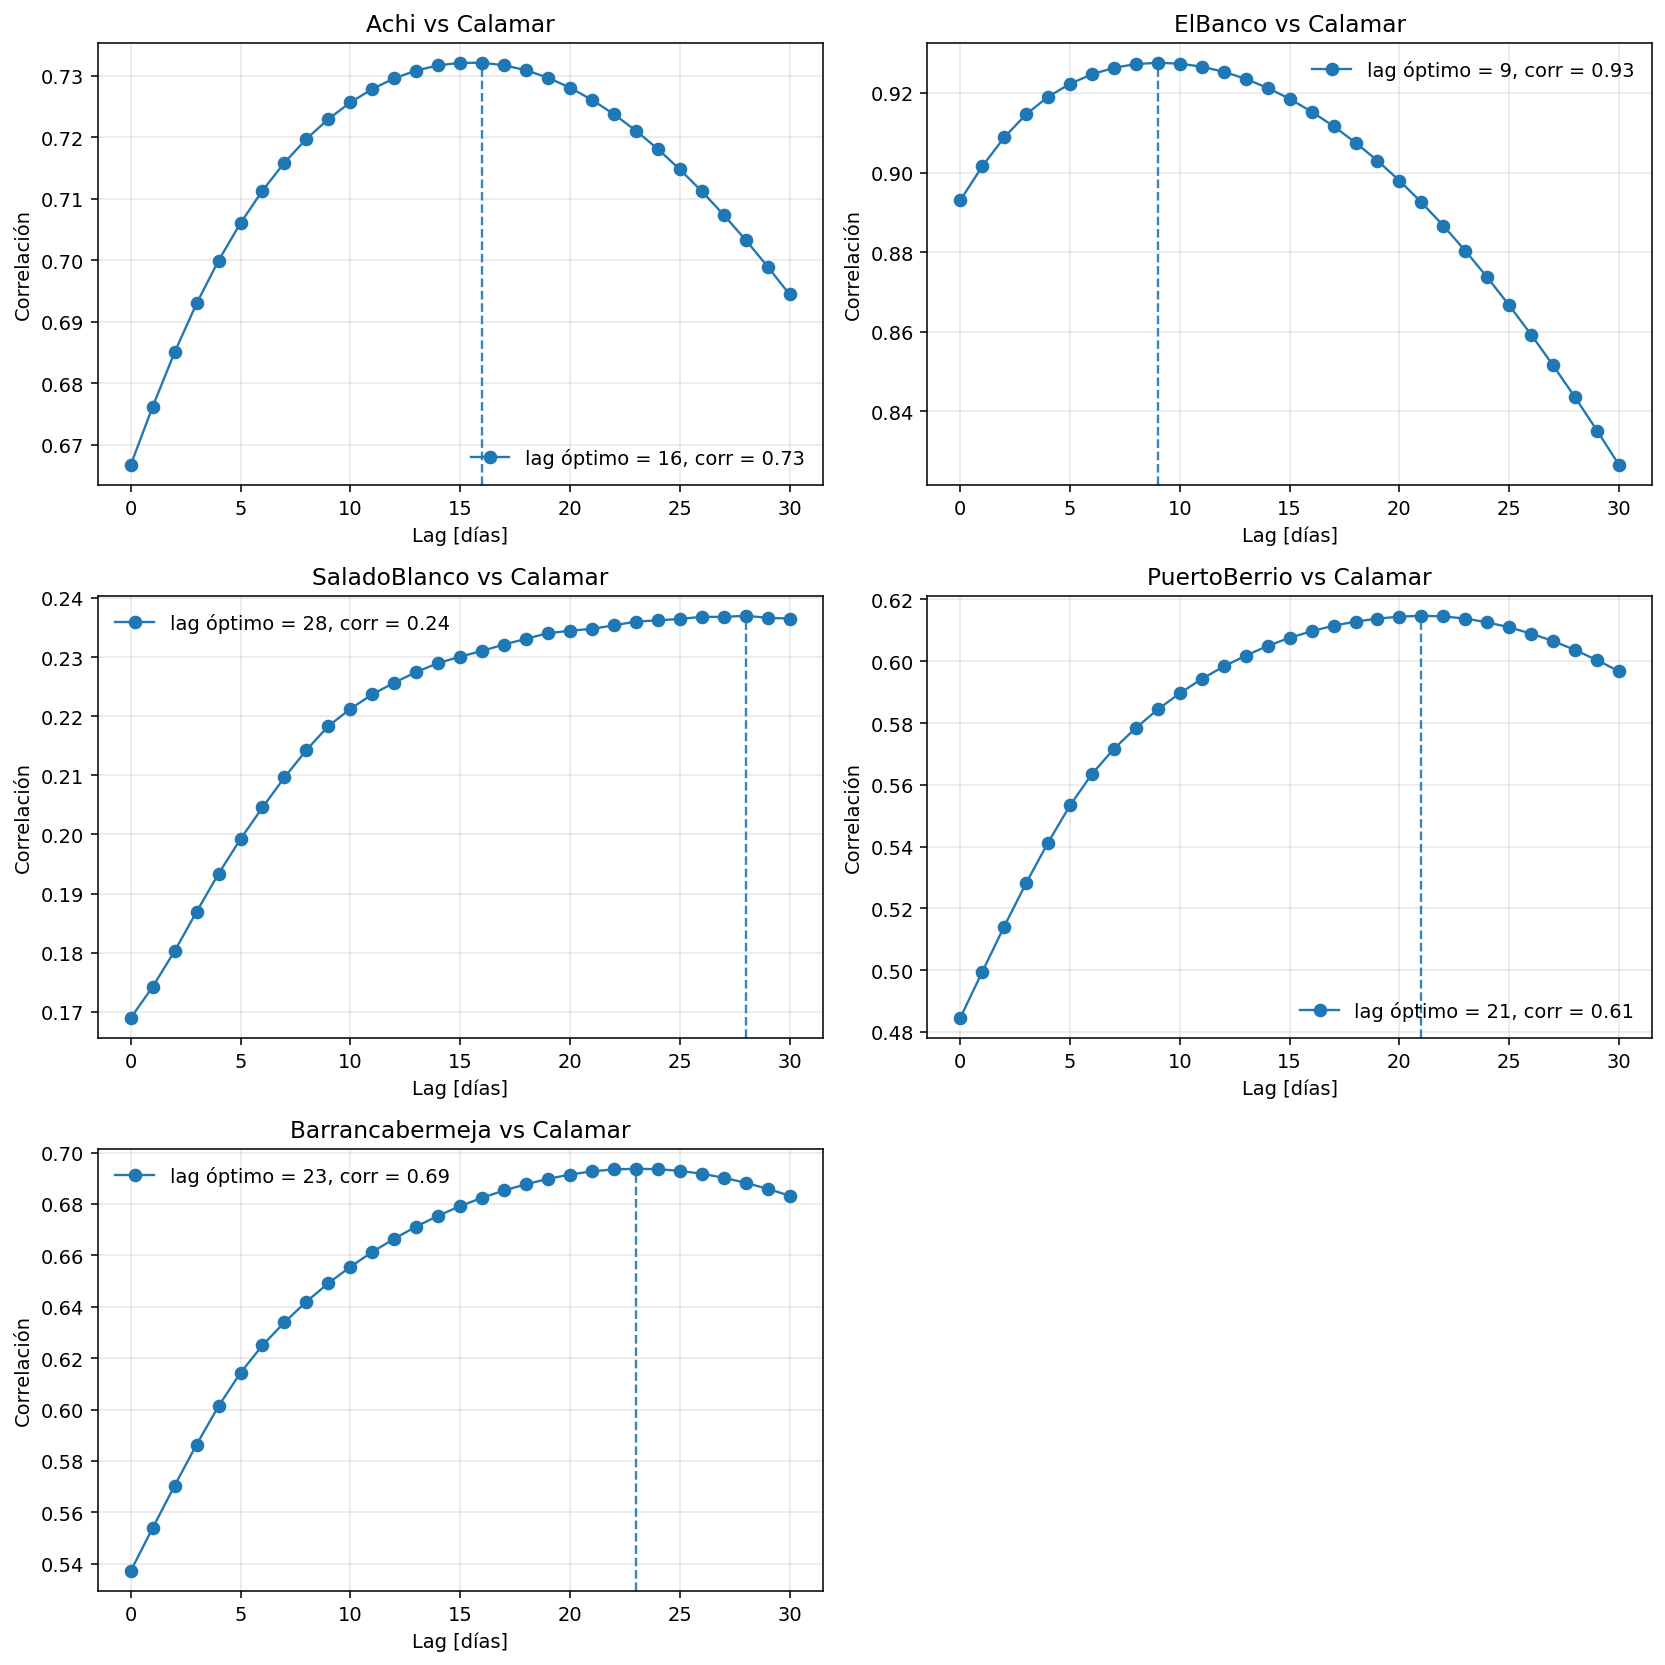

In [57]:

import math
import pandas as pd
import matplotlib.pyplot as plt

# Correlación cruzada
# lag > 0 significa que la explicativa ocurre antes que Calamar

def correlacion_cruzada(df, explicativa, target="Calamar", max_lag=30):
    resultados = []
    for lag in range(max_lag + 1):
        r = df[explicativa].shift(lag).corr(df[target])
        resultados.append((lag, r))

    out = pd.DataFrame(resultados, columns=["lag_dias", "corr"])
    mejor = out.loc[out["corr"].idxmax()]

    return out, int(mejor["lag_dias"]), float(mejor["corr"])



target = "Calamar"
explicativas = [col for col in df.columns if col not in ["Fecha", target]]

# Diccionarios para guardar resultados
ccf_resultados = {}
lags_optimos = {}
corrs_optimas = {}


for est in explicativas:
    ccf, lag, corr = correlacion_cruzada(df, est, target=target, max_lag=30)

    ccf_resultados[est] = ccf
    lags_optimos[est] = lag
    corrs_optimas[est] = corr

    print(f"{est} -> {target}: mejor lag = {lag} días, correlación = {corr:.4f}")

# Desplazar series
for est in explicativas:
    df[f"{est}_shift"] = df[est].shift(lags_optimos[est])

# Recortar NaNs de bordes
cols_finales = [target] + [f"{est}_shift" for est in explicativas]

first_idx = max(df[col].first_valid_index() for col in cols_finales)
last_idx  = min(df[col].last_valid_index()  for col in cols_finales)

df = df.loc[first_idx:last_idx].reset_index(drop=True)

# Tabla resumen
df_lags = pd.DataFrame({
    "Estacion": explicativas,
    "Lag_optimo_dias": [lags_optimos[e] for e in explicativas],
    "Correlacion_max": [corrs_optimas[e] for e in explicativas]
}).sort_values("Correlacion_max", ascending=False).reset_index(drop=True)

# Gráficas
n = len(explicativas)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows), dpi=140)
axes = axes.flatten()

for ax, est in zip(axes, explicativas):
    ccf = ccf_resultados[est]
    lag = lags_optimos[est]
    corr = corrs_optimas[est]

    linea, = ax.plot(
        ccf["lag_dias"],
        ccf["corr"],
        marker="o",
        lw=1.2,
        label=f"{est}"
    )

    ymin, ymax = ax.get_ylim()

    ax.vlines(
        lag,
        ymin=ymin,
        ymax=corr,
        color=linea.get_color(),
        linestyle="--",
        linewidth=1.2,
        alpha=0.9
    )

    ax.scatter(lag, corr, s=30, color=linea.get_color(), zorder=3)

    ax.set_ylim(ymin, ymax)
    ax.set_title(f"{est} vs {target}")
    ax.set_xlabel("Lag [días]")
    ax.set_ylabel("Correlación")
    ax.grid(True, alpha=0.3)
    ax.legend([f"lag óptimo = {lag}, corr = {corr:.2f}"], frameon=False)


for j in range(len(explicativas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Guardar series finales
cols_guardar = ["Fecha", target] + [f"{est}" for est in explicativas]

df_guardar = df[cols_guardar].copy()
df_guardar["Fecha"] = df_guardar["Fecha"].dt.strftime("%Y-%m-%d")

df_guardar.to_csv(
    r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv",
    index=False
)


Entonces, una vez se conoce el lag representativo, procedemos a realizar el EDA con las series desplazadas.